# Домашнее задание 6: классификация текстов

В этом домашнем задании вам предстоит построить классификатор текстов!

Данные мы будем использовать из Kaggle соревнования: https://www.kaggle.com/competitions/nlp-getting-started/data 


Оттуда надо скачать файл train.csv. На обучающую и тестовую выборки его поделим кодом ниже, менять его не надо!

Мы будем работать с датасетом постов из твиттера. Нам предстоит решать задачу бинарной классификации - определять содержатся ли в твитте информация о настоящей катастрофе/инциденте или нет.

In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:
data = pd.read_csv('train.csv')

In [3]:
data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, random_state=42)

## Задание 1 (0.5 балла)

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой.

In [5]:
print(train.isnull().sum())
print(test.isnull().sum())
train = train.fillna('')
test = test.fillna('')
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

id             0
keyword       44
location    1760
text           0
target         0
dtype: int64
id            0
keyword      17
location    773
text          0
target        0
dtype: int64
0
0


## Задание 2 (1 балл)
Давайте немного посмотрим на наши данные. Визуализируйте (где явно просят) или выведете информацию о следующем:

1. Какое распределение классов в обучающей выборке?


In [6]:
class_distribution = train['target'].value_counts()
print(class_distribution)
print(class_distribution / len(train))

target
0    3024
1    2305
Name: count, dtype: int64
target
0    0.567461
1    0.432539
Name: count, dtype: float64


2. Посмотрите на колонку "keyword" - возьмите 10 наиболее встречающихся значений, постройте ступенчатую диаграмму распределения классов в зависимости от значения keyword, сделайте выводы.

In [7]:
popular_keywords = train['keyword'].value_counts().head(10).index.tolist()
print(popular_keywords)
train_popular_keywords = train[train['keyword'].isin(popular_keywords)]


['', 'damage', 'siren', 'wreckage', 'fatalities', 'deluge', 'nuclear%20reactor', 'emergency', 'derail', 'harm']


<Figure size 1500x600 with 0 Axes>

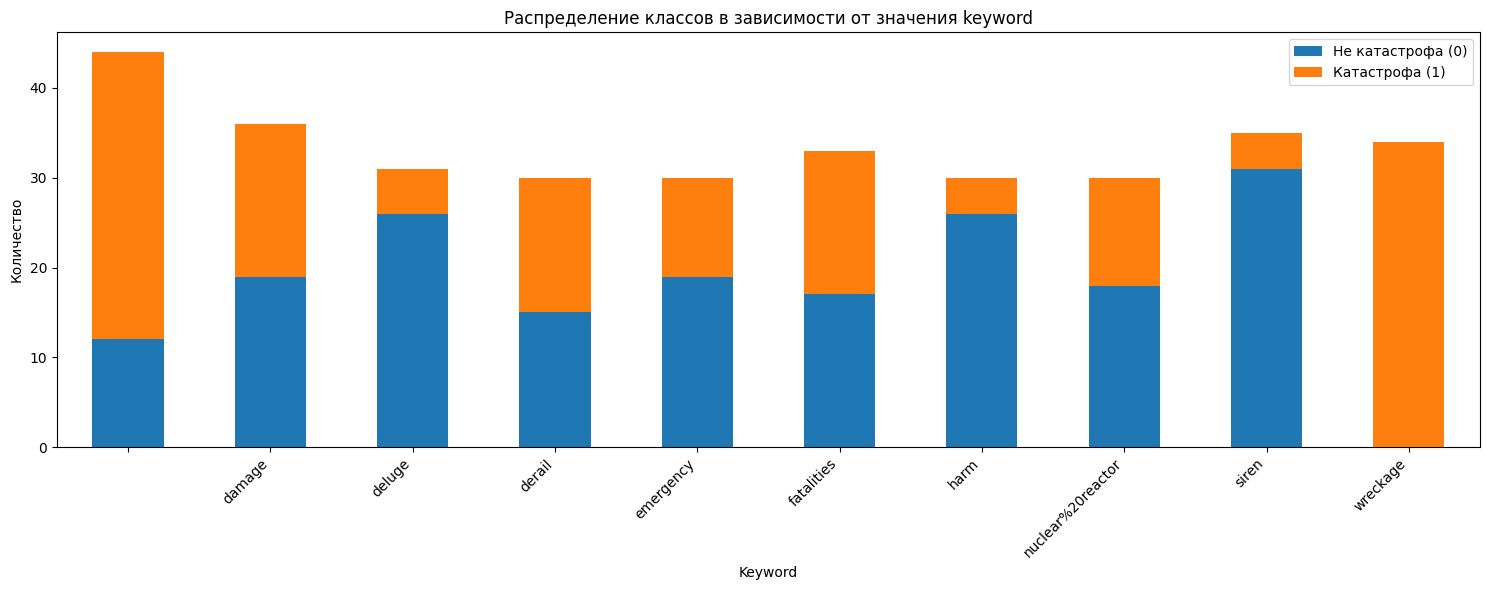

In [8]:
plt.figure(figsize=(15, 6))

# Группировка по keyword и target, подсчет количества
keyword_class_counts = train_popular_keywords.groupby(['keyword', 'target']).size().unstack(fill_value=0)

# Построение stacked bar chart
keyword_class_counts.plot(kind='bar', stacked=True, figsize=(15, 6))
plt.title('Распределение классов в зависимости от значения keyword')
plt.xlabel('Keyword')
plt.ylabel('Количество')
plt.legend(['Не катастрофа (0)', 'Катастрофа (1)'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Выводы**: TODO

## Задание 3 (0.5 балла) 

В этом задании предлагается объединить все три текстовых столбца в один (просто сконкатенировать cтроки) и убрать столбец с индексом.

In [9]:
train.loc[[6590, 7122, 2769]]

,id,keyword,location,text,target
6590,9436,survivors,"Marietta, GA",Stemming from my #Cubs talk- the team rosters ...,1
7122,10203,violent%20storm,,If you were the NWS wth a rotating storm w/ a ...,1
2769,3980,devastation,Atlanta g.a.,http://t.co/Gxgm1T3W0J From Devastation to Ela...,0


In [10]:
train['text_combined'] = train['keyword'].astype(str) + ' ' + train['location'].astype(str) + ' ' + train['text'].astype(str)

test['text_combined'] = test['keyword'].astype(str) + ' ' + test['location'].astype(str) + ' ' + test['text'].astype(str)

train_new = train[['text_combined', 'target']].copy()
test_new = test[['text_combined', 'target']].copy()

train_new = train_new.rename(columns={'text_combined': 'text'})
test_new = test_new.rename(columns={'text_combined': 'text'})

In [11]:
train_new.loc[[6590, 7122, 2769]]

,text,target
6590,"survivors Marietta, GA Stemming from my #Cubs ...",1
7122,violent%20storm If you were the NWS wth a rot...,1
2769,devastation Atlanta g.a. http://t.co/Gxgm1T3W0...,0


## Задание 4 (0.5 балла)

Далее мы будем пока работать только с train частью.

1. Предобработайте данные (train часть) с помощью CountVectorizer.
2. Какого размера получилась матрица?


In [12]:
import string
from sklearn.feature_extraction.text import CountVectorizer 

vectorizer = CountVectorizer()

# Обучаем на текстах из обучающей выборки и преобразуем их
X_train = vectorizer.fit_transform(train_new['text'])

print(f"Размер матрицы признаков: {X_train.shape}")
print(f"Количество текстов: {X_train.shape[0]}")
print(f"Количество уникальных слов: {X_train.shape[1]}")

Размер матрицы признаков: (5329, 18455)
Количество текстов: 5329
Количество уникальных слов: 18455


## Задание 5 (1 балл)

В предыдущем пункте у вас должна была получиться достаточно большая матрица.
Если вы взгляните на текст, то увидете, что там есть множество специальных символов, ссылок и прочего мусора.

Давайте также посмотрим на словарь, который получился в результате построения CountVectorizer, его можно найти в поле vocabulary_ инстанса этого класса. Давайте напишем функцию, которая печает ответы на следующие вопросы:

1. Найдите в этом словаре все слова, которые содержат цифры. Сколько таких слов нашлось?

2. Найдите все слова, которые содержат символы пунктуации. Сколько таких слов нашлось? 

3. Сколько хэштегов (токен начинается на #) и упоминаний (токен начинается на @) осталось в словаре?

In [13]:
def contains_digit(s: str) -> bool:
    # Проверка, содержит ли слово цифры
    return any(char.isdigit() for char in s)

def contains_punctuation(s: str) -> bool:
    # Проверка, содержит ли слово пунктуацию
    return any(char in string.punctuation for char in s)

def is_hashtag(s: str) -> bool:
    # Проверка, является ли слово хэштегом
    return s.startswith('#')
    
def is_mention(s: str) -> bool:
    # Проверка, является ли слово упоминанием
    return s.startswith('@')

def investigate_vocabulary(vocabulary):
    words = list(vocabulary.keys())
    
    words_with_digit = [word for word in words if contains_digit(word)]
    words_with_punctuation = [word for word in words if contains_punctuation(word)]
    hashtags = [word for word in words if is_hashtag(word)]
    mentions = [word for word in words if is_mention(word)]
    
    print('With digit:      ', len(words_with_digit))
    print('With punctuation:', len(words_with_punctuation))
    print('Hashtags:        ', len(hashtags))
    print('Mentions:        ', len(mentions))




In [14]:
dummy_vocab = {'th1nk' : 0,
               'think333' : 1,
               'think.' : 2,
               'th!nk' : 3,
               'th...nk' : 4,
               '#think' : 5,
               '@think' : 6,
               '@thinking':7,
               '@nothink' : 8,
               'think' : 9}
investigate_vocabulary(dummy_vocab)

With digit:       2
With punctuation: 7
Hashtags:         1
Mentions:         3


In [15]:
investigate_vocabulary(vectorizer.vocabulary_)

With digit:       3812
With punctuation: 315
Hashtags:         0
Mentions:         0


## Задание 6 (0.5 балла)

Вспомним, что на семинаре по текстам мы узнали, что в nltk есть специальный токенизатор для текстов - TweetTokenizer. Попробуем применить CountVectorizer с этим токенизатором. Ответьте на все вопросы из предыдущего пункта для TweetTokenizer и сравните результаты.

In [16]:
from nltk.tokenize import TweetTokenizer
import nltk
import string

# Чтобы узнать, какие параметры есть у этого токенайзера - используйте help(TweetTokenizer)
# Для того, чтобы передать токенайзер в CountVectorizer используйте параметр tokenizer

# Создаем TweetTokenizer с оптимальными параметрами для твитов
# help(TweetTokenizer) чтобы увидеть все параметры
tweet_tokenizer = TweetTokenizer(
    preserve_case=False,  # Приводим к нижнему регистру
    reduce_len=True,      # Сокращаем повторяющиеся символы (например, "heeeelllo" -> "heelllo")
    strip_handles=True    # Удаляем упоминания (@username)
)

# Создаем CountVectorizer с TweetTokenizer
vectorizer_tweet = CountVectorizer(tokenizer=tweet_tokenizer.tokenize)

# Обучаем и преобразуем данные
X_train_tweet = vectorizer_tweet.fit_transform(train_new['text'])

/Users/pr1zrak228/Library/Python/3.13/lib/python/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [17]:
vocabulary_tweet = vectorizer_tweet.vocabulary_
investigate_vocabulary(vocabulary_tweet)


With digit:       3645
With punctuation: 5669
Hashtags:         1470
Mentions:         10


In [18]:
investigate_vocabulary(vectorizer.vocabulary_)

print(f"Стандартный CountVectorizer: {X_train.shape}")
print(f"CountVectorizer с TweetTokenizer: {X_train_tweet.shape}")
print(f"Разница в количестве признаков: {X_train.shape[1] - X_train_tweet.shape[1]}")

With digit:       3812
With punctuation: 315
Hashtags:         0
Mentions:         0
Стандартный CountVectorizer: (5329, 18455)
CountVectorizer с TweetTokenizer: (5329, 17989)
Разница в количестве признаков: 466


Количество признаков: TweetTokenizer обычно создает меньше признаков, так как лучше обрабатывает особенности твитов (смайлики, упоминания, хэштеги)

Слова с пунктуацией: Должно стать значительно меньше, так как TweetTokenizer правильно обрабатывает пунктуацию как отдельные токены или часть слов

Хэштеги и упоминания: TweetTokenizer с параметром strip_handles=True удаляет упоминания, поэтому их количество должно быть 0. Хэштеги сохраняются как отдельные токены

Слова с цифрами: Количество может немного уменьшиться, так как TweetTokenizer лучше обрабатывает токены с цифрами

Качество токенизации: TweetTokenizer специально разработан для твитов, поэтому он лучше справляется с:

Эмодзи и смайликами

Повторяющимися символами

Хэштегами и упоминаниями

Специфическими для твитов сокращениями

## Задание 7 (2 балла)

В scikit-learn мы можем оценивать процесс подсчета матрицы через CountVectorizer. У CountVectorizer, как и у других наследников \_VectorizerMixin, есть аргумент tokenizer и preprocessor. preprocessor применится в самом начале к каждой строке вашего датасета, tokenizer же должен принять строку и вернуть токены.
Давайте напишем кастомный токенайзер, которые сделает все, что нам нужно: 

0. Приведет все буквы к нижнему регистру
1. Разобьет текст на токены с помощью TweetTokenizer из пакета nltk
2. Удалит все токены содержащие не латинские буквы, кроме смайликов (будем считать ими токены содержащие только пунктуацию и, как минимум, одну скобочку) и хэштегов, которые после начальной # содержат только латинские буквы.
3. Удалит все токены, которые перечислены в nltk.corpus.stopwords.words('english')
4. Проведет стемминг с помощью SnowballStemmer



In [20]:
import string
import re
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import ssl
from typing import List
import nltk

# Инициализируем стеммер и список стоп-слов
stemmer = SnowballStemmer('english')
stop_words = set(stopwords.words('english'))

def contains_only_latin_letters(s: str) -> bool:
    """Проверка, содержит ли слово только латинские буквы"""
    return all(char.isalpha() and char.isascii() for char in s)

def is_emoji(s: str) -> bool:
    """Проверка, является ли слово смайликом (содержит только пунктуацию и хотя бы одну скобочку)"""
    # Проверяем, что все символы - знаки пунктуации
    if not all(char in string.punctuation for char in s):
        return False
    # Проверяем, есть ли хотя бы одна скобочка
    return any(char in '()[]{}' for char in s)

def is_hashtag(s: str) -> bool:
    """Проверка, является ли слово хэштегом (начинается с # и после # только латинские буквы)"""
    if not s.startswith('#'):
        return False
    # Проверяем, что после # идут только латинские буквы
    if len(s) == 1:
        return False
    return all(char.isalpha() and char.isascii() for char in s[1:])

def custom_tokenizer(s: str) -> List[str]:
    """
    Кастомный токенайзер:
    0. Приводит все буквы к нижнему регистру
    1. Разбивает текст на токены с помощью TweetTokenizer
    2. Удаляет все токены, содержащие не латинские буквы, кроме:
       - смайликов (токены, содержащие только пунктуацию и хотя бы одну скобочку)
       - хэштегов (токены, начинающиеся с # и содержащие после # только латинские буквы)
    3. Удаляет все стоп-слова
    4. Проводит стемминг с помощью SnowballStemmer
    """
    # 0. Приводим к нижнему регистру
    s = s.lower()
    
    # 1. Токенизация с помощью TweetTokenizer
    tokenizer = TweetTokenizer(
        preserve_case=False,  # уже привели к нижнему регистру
        reduce_len=True,      # сокращаем повторяющиеся символы
        strip_handles=False   # не удаляем упоминания, чтобы потом их отфильтровать
    )
    tokens = tokenizer.tokenize(s)
    
    # 2. Фильтрация токенов
    filtered_tokens = []
    for token in tokens:
        # Сохраняем смайлики
        if is_emoji(token):
            filtered_tokens.append(token)
        # Сохраняем хэштеги
        elif is_hashtag(token):
            filtered_tokens.append(token)
        # Сохраняем слова только из латинских букв
        elif contains_only_latin_letters(token):
            filtered_tokens.append(token)
        # Остальные токены отбрасываем
    
    # 3. Удаление стоп-слов
    filtered_tokens = [token for token in filtered_tokens if token not in stop_words]
    
    # 4. Стемминг
    stemmed_tokens = [stemmer.stem(token) for token in filtered_tokens]
    
    return stemmed_tokens

In [21]:
custom_tokenizer('She LOVES painting :-) #art')

['love', 'paint', ':-)', '#art']

Продемонстрируйте работу вашей функции на первых десяти текстах в обучающей выборке.

In [22]:
for i in range(10):
    original_text = train_new['text'].iloc[i]
    tokenized_text = custom_tokenizer(original_text)
    
    print(f"\n{i+1}. Оригинальный текст ({len(original_text)} символов):")
    print(f"   {original_text[:200]}..." if len(original_text) > 200 else f"   {original_text}")
    print(f"   Токены после обработки ({len(tokenized_text)} токенов):")
    print(f"   {tokenized_text}")
    print("-" * 80)


1. Оригинальный текст (157 символов):
   bridge%20collapse  Ashes 2015: AustraliaÛªs collapse at Trent Bridge among worst in history: England bundled out Australia for 60 ... http://t.co/t5TrhjUAU0
   Токены после обработки (12 токенов):
   ['bridg', 'ash', 'australia', 'collaps', 'trent', 'bridg', 'among', 'worst', 'histori', 'england', 'bundl', 'australia']
--------------------------------------------------------------------------------

2. Оригинальный текст (154 символов):
   hail Carol Stream, Illinois GREAT MICHIGAN TECHNIQUE CAMP
B1G THANKS TO @bmurph1019 
@hail_Youtsey . @termn8r13 
#GoBlue #WrestleOn http://t.co/OasKgki6Qj
   Токены после обработки (11 токенов):
   ['hail', 'carol', 'stream', 'illinoi', 'great', 'michigan', 'techniqu', 'camp', 'thank', '#goblu', '#wrestleon']
--------------------------------------------------------------------------------

3. Оригинальный текст (101 символов):
   police Houston  CNN: Tennessee movie theater shooting suspect killed by police 

## Задание 8 (1 балл)

1. Примените CountVectorizer с реализованным выше токенизатором к обучающим и тестовым выборкам.


In [23]:
vectorizer = CountVectorizer(
    tokenizer=custom_tokenizer,  # используем наш кастомный токенизатор
    token_pattern=None,          # отключаем стандартный паттерн, т.к. используем свой токенизатор
    lowercase=False              # отключаем встроенный lowercasing, т.к. это уже делает токенизатор
)
# Обучаем векторизатор на обучающих данных и преобразуем их
X_train_custom = vectorizer.fit_transform(train_new['text'])
print(f"Размер матрицы признаков для обучающей выборки: {X_train_custom.shape}")

# Преобразуем тестовые данные
X_test_custom = vectorizer.transform(test_new['text'])
print(f"Размер матрицы признаков для тестовой выборки: {X_test_custom.shape}")

# Получаем целевые переменные
y_train = train_new['target']
y_test = test_new['target']

print(f"\nКоличество признаков после векторизации: {X_train_custom.shape[1]}")
print(f"Количество ненулевых элементов в обучающей матрице: {X_train_custom.nnz}")
print(f"Разреженность матрицы: {100 * (1 - X_train_custom.nnz / (X_train_custom.shape[0] * X_train_custom.shape[1])):.2f}%")

Размер матрицы признаков для обучающей выборки: (5329, 10480)
Размер матрицы признаков для тестовой выборки: (2284, 10480)

Количество признаков после векторизации: 10480
Количество ненулевых элементов в обучающей матрице: 51079
Разреженность матрицы: 99.91%


2. Обучите LogisticRegression на полученных признаках.


In [25]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(
    max_iter=1000,           # увеличиваем количество итераций для сходимости
    C=1.0,                   # параметр регуляризации
    random_state=42,         # для воспроизводимости
)

logreg.fit(X_train_custom, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

3. Посчитайте метрику f1-score на тестовых данных.

In [26]:
from sklearn.metrics import f1_score

y_pred = logreg.predict(X_test_custom)

# Считаем f1-score
f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.4f}")

F1 score: 0.7508


## Задание 9 (1 балл)

1. Повторите 8 задание, но с tf-idf векторизатором. Как изменилось качество?


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1
# Создаем TfidfVectorizer с кастомным токенизатором
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=custom_tokenizer,
    token_pattern=None,
    lowercase=False
)

# Преобразуем обучающие и тестовые данные
X_train_tfidf = tfidf_vectorizer.fit_transform(train_new['text'])
X_test_tfidf = tfidf_vectorizer.transform(test_new['text'])

print(f"Размер матрицы признаков (TfidfVectorizer): {X_train_tfidf.shape}")

# Обучаем логистическую регрессию
logreg_tfidf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)

logreg_tfidf.fit(X_train_tfidf, y_train)

# Предсказываем и считаем f1-score
y_pred_tfidf = logreg_tfidf.predict(X_test_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf)
print(f"F1 score (TfidfVectorizer): {f1_tfidf:.4f}")

Размер матрицы признаков (TfidfVectorizer): (5329, 10480)
F1 score (TfidfVectorizer): 0.7428


In [ ]:
Твиты о катастрофах могут содержать специфические ключевые слова, которые встречаются редко, но являются важными. tf-idf могла уменьшить вес этих важных, но редких слов.

1. **Ответ:** TODO

2. Мы можем еще сильнее уменьшить размер нашей матрицы, если отбросим значения df близкие к единице. Скорее всего такие слова не несут много информации о категории, так как встречаются достаточно часто. Ограничьте максимальный df в параметрах TfIdfVectorizer, поставьте верхнюю границу равную 0.9. Как изменился размер матрицы, как изменилось качество?


In [28]:
# 2
tfidf_vectorizer_maxdf = TfidfVectorizer(
    tokenizer=custom_tokenizer,
    token_pattern=None,
    lowercase=False,
    max_df=0.9  # Ограничиваем максимальную document frequency
)

# Преобразуем данные
X_train_tfidf_maxdf = tfidf_vectorizer_maxdf.fit_transform(train_new['text'])
X_test_tfidf_maxdf = tfidf_vectorizer_maxdf.transform(test_new['text'])

print(f"Размер матрицы признаков (max_df=0.9): {X_train_tfidf_maxdf.shape}")

# Обучаем логистическую регрессию
logreg_tfidf_maxdf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)

logreg_tfidf_maxdf.fit(X_train_tfidf_maxdf, y_train)

# Предсказываем и считаем f1-score
y_pred_tfidf_maxdf = logreg_tfidf_maxdf.predict(X_test_tfidf_maxdf)
f1_tfidf_maxdf = f1_score(y_test, y_pred_tfidf_maxdf)
print(f"F1 score (max_df=0.9): {f1_tfidf_maxdf:.4f}")

Размер матрицы признаков (max_df=0.9): (5329, 10480)
F1 score (max_df=0.9): 0.7428


In [ ]:
Матрица и качество никак не изменились

2. **Ответ:** TODO

3. Также мы можем уменьшить размер матрицы, удаляя слова со слишком маленьким df. Удалось ли добиться улучшения качества? 

In [29]:
# 3
tfidf_vectorizer_mindf = TfidfVectorizer(
    tokenizer=custom_tokenizer,
    token_pattern=None,
    lowercase=False,
    min_df=3  # Удаляем слова, встречающиеся менее чем в 3 документах
)

# Преобразуем данные
X_train_tfidf_mindf = tfidf_vectorizer_mindf.fit_transform(train_new['text'])
X_test_tfidf_mindf = tfidf_vectorizer_mindf.transform(test_new['text'])

print(f"Размер матрицы признаков (min_df=3): {X_train_tfidf_mindf.shape}")

# Обучаем логистическую регрессию
logreg_tfidf_mindf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)

logreg_tfidf_mindf.fit(X_train_tfidf_mindf, y_train)

# Предсказываем и считаем f1-score
y_pred_tfidf_mindf = logreg_tfidf_mindf.predict(X_test_tfidf_mindf)
f1_tfidf_mindf = f1_score(y_test, y_pred_tfidf_mindf)
print(f"F1 score (min_df=3): {f1_tfidf_mindf:.4f}")

Размер матрицы признаков (min_df=3): (5329, 3139)
F1 score (min_df=3): 0.7439


In [ ]:
небольшое улучшение, так как удаление редких слов (опечатки, уникальные термины) часто помогает обобщению модели.

3. **Ответ:** TODO

## Задание 10 (1 балл)

Еще один популяпный трюк, который позволит уменьшить количество признаков называется hashing trick. Его суть в том, то мы случайно группируем признаки ииии  ..... складываем их! А потом удаляем исходные признаки. В итоге все наши признаки это просто суммы исходных. Звучит странно, но это отлично работает. Давайте проверим этот трюк в нашем сеттинге.
Также при таком подходе вам не нужно хранить словарь token->index, что тоже иногда полезно.

1. Повторите задание 8 с HashingVectorizer, укажите количество фичей равное 5000.


In [31]:
from sklearn.feature_extraction.text import HashingVectorizer

hashing_vectorizer = HashingVectorizer(
    tokenizer=custom_tokenizer,
    token_pattern=None,
    lowercase=False,
    n_features=5000,  # Количество фичей
)

X_train_hash = hashing_vectorizer.fit_transform(train_new['text'])
X_test_hash = hashing_vectorizer.transform(test_new['text'])

print(f"Размер матрицы признаков (HashingVectorizer): {X_train_hash.shape}")

logreg_hash = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)

logreg_hash.fit(X_train_hash, y_train)

y_pred_hash = logreg_hash.predict(X_test_hash)
f1_hash = f1_score(y_test, y_pred_hash)
print(f"F1 score (HashingVectorizer, n_features=5000): {f1_hash:.4f}")

Размер матрицы признаков (HashingVectorizer): (5329, 5000)
F1 score (HashingVectorizer, n_features=5000): 0.7184


2. Какой из подходов показал самый высокий результат?

2. **Ответ:** TODO

In [ ]:
CountVectorizer показал лучший результат, что говорит о том, что для этой задачи бинарные признаки (наличие/отсутствие слов) и их частоты работают эффективнее всего.

## Задание 11 (1 балл)

В этом задании нужно добиться f1 меры хотя в 0.75 на тестовых данных.

In [ ]:
# -- YOUR CODE HERE --